Dataset Loading


In [ ]:
!pip install gdown
import gdown

file_id = "1DyZkbA91MHQP8C3SzE-rnRKdaZUba7tS"

gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.zip", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1DyZkbA91MHQP8C3SzE-rnRKdaZUba7tS
From (redirected): https://drive.google.com/uc?id=1DyZkbA91MHQP8C3SzE-rnRKdaZUba7tS&confirm=t&uuid=8de707bc-47c6-4178-999c-d9f45d05b454
To: /content/data.zip
100%|██████████| 3.59G/3.59G [00:47<00:00, 74.9MB/s]


'data.zip'

In [ ]:
import zipfile

with zipfile.ZipFile('data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/data')


In [ ]:
import os
os.listdir('/content/data')

['archive', '__MACOSX']

In [ ]:
os.listdir('/content/data/archive')

['dataset', 'repository', '.DS_Store', 'README.md']

In [ ]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),   # make all images same size
    transforms.ToTensor(),           # convert to tensor
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))  # for RGB images
])

In [ ]:
!ls /content/data/archive/dataset



1_normal  2_cataract  2_glaucoma  3_retina_disease


In [ ]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder(
    root='/content/data/archive/dataset',
    transform=transform
)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['1_normal', '2_cataract', '2_glaucoma', '3_retina_disease']
Total images: 601


In [ ]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [ ]:
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


Train size: 480
Test size: 121


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 15
Test batches: 4


In [ ]:
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)

Image shape: torch.Size([32, 3, 128, 128])
Label shape: torch.Size([32])


In [ ]:
from collections import Counter

labels = [label for _, label in dataset]
class_counts = Counter(labels)

print("Class Distribution:")
for i, count in class_counts.items():
    print(f"{dataset.classes[i]}: {count}")

Class Distribution:
1_normal: 300
2_cataract: 100
2_glaucoma: 101
3_retina_disease: 100


# Eye Disease Classification using Deep Learning

This dataset contains images of human eyes categorized into 4 classes:

- Normal
- Cataract
- Glaucoma
- Retina Disease

The dataset is organized into folders, each representing one class.

Total classes: 4  
Image type: RGB images  
Image size: Resized to 128×128 for training

Goal:
To design and compare two classifiers:
1. Artificial Neural Network (ANN)
2. Convolutional Neural Network (CNN)



In [ ]:
!pip install torch torchvision matplotlib -q

## 1. Imports


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
classes = ['normal', 'cataract', 'glaucoma', 'retina_disease']

## 2.Data Loading and Transformations

Medical image datasets are usually limited in size, which can lead to overfitting.


These transformations ensure that the model does not memorize training data and performs well on unseen data.

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((128,128)),               # standard size
    transforms.RandomHorizontalFlip(),          # augmentation
    transforms.RandomRotation(10),              # augmentation
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # augmentation
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

transform_test = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

In [ ]:
dataset = ImageFolder(
    root='/content/data/archive/dataset',
    transform=transform_train
)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['1_normal', '2_cataract', '2_glaucoma', '3_retina_disease']
Total images: 601


In [ ]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

test_dataset.dataset.transform = transform_test

trainloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
testloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train batches:", len(trainloader))
print("Test batches:", len(testloader))

images, labels = next(iter(trainloader))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)

Train size: 480
Test size: 121
Train batches: 15
Test batches: 4
Image shape: torch.Size([32, 3, 128, 128])
Label shape: torch.Size([32])


## 3.Utility Functions

### 3a. Training Loop (returns history for plotting)

We define a training function that:

- Trains the model for multiple epochs
- Tracks training loss and validation loss
- Tracks validation accuracy
- Supports regularization using weight decay

Why this is important:
- Helps visualize learning using loss curves
- Detects overfitting (train vs validation gap)


In [ ]:
def evaluate(model, loader, return_metrics=False):
    model.eval()

    criterion = nn.CrossEntropyLoss()
    correct, total, total_loss = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100.0 * correct / total
    avg_loss = total_loss / len(loader)

    if return_metrics:
        return avg_loss, acc

    print(f"Test Accuracy: {acc:.2f}% | Loss: {avg_loss:.4f}")
    return acc

In [ ]:
def train(model, trainloader, valloader=None, epochs=10, lr=0.001, use_reg=True):
    model.to(device)

    criterion = nn.CrossEntropyLoss()

    if use_reg:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    history = {
        'train_loss': [],
        'train_acc':  [],
        'val_loss':   [],
        'val_acc':    [],
        'lr':         []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct      = 0
        total        = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)

            _, predicted = torch.max(outputs.data, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(trainloader)
        train_acc  = 100 * correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        scheduler.step(train_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        if valloader:
            val_loss, val_acc = evaluate(model, valloader, return_metrics=True)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            # ✅ || separator, no LR, val_acc multiplied by 100 if evaluate() returns 0-1
            print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}% || Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")
        else:
            print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}%")

    return history

### 3B.Evaluation


In [ ]:
def evaluate(model, loader, return_metrics=False):

    model.eval()

    criterion = nn.CrossEntropyLoss()

    correct = 0
    total = 0
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    avg_loss = total_loss / len(loader)

    if return_metrics:
        return avg_loss, accuracy

    print(f"Test Accuracy: {accuracy:.2f}% | Loss: {avg_loss:.4f}")
    return accuracy

## 4.Baseline Models

### 4A.ANN

In [ ]:
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*128*3, 256),   # reduced from 512 — 25M params was too many
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.model(x)

ann_model   = ANN()
ann_history = train(ann_model, trainloader, testloader, epochs=15)




Epoch 1: Train Loss=3.9443, Train Acc=27.92% || Val Loss=3.0330, Val Acc=52.89%
Epoch 2: Train Loss=2.1134, Train Acc=33.33% || Val Loss=1.4820, Val Acc=52.89%
Epoch 3: Train Loss=1.3599, Train Acc=38.54% || Val Loss=1.6442, Val Acc=51.24%
Epoch 4: Train Loss=1.3273, Train Acc=46.67% || Val Loss=1.1415, Val Acc=61.16%
Epoch 5: Train Loss=1.2634, Train Acc=46.04% || Val Loss=1.4982, Val Acc=22.31%
Epoch 6: Train Loss=1.3138, Train Acc=45.42% || Val Loss=1.2739, Val Acc=53.72%
Epoch 7: Train Loss=1.2086, Train Acc=50.62% || Val Loss=1.3515, Val Acc=33.06%
Epoch 8: Train Loss=1.2185, Train Acc=51.46% || Val Loss=1.1144, Val Acc=61.98%
Epoch 9: Train Loss=1.1655, Train Acc=54.58% || Val Loss=1.5318, Val Acc=47.93%
Epoch 10: Train Loss=1.2761, Train Acc=50.42% || Val Loss=1.2499, Val Acc=30.58%
Epoch 11: Train Loss=1.1958, Train Acc=50.83% || Val Loss=1.1187, Val Acc=58.68%
Epoch 12: Train Loss=1.1504, Train Acc=53.96% || Val Loss=1.2186, Val Acc=48.76%
Epoch 13: Train Loss=1.1474, Train Ac

### 4B.CNN

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*32*32, 128),
            nn.ReLU(),
            nn.Linear(128, 4)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x


#train
cnn_model = CNN()

cnn_history = train(cnn_model, trainloader, testloader, epochs=20)




Epoch 1: Train Loss=1.5850, Train Acc=34.58% || Val Loss=1.2874, Val Acc=52.89%
Epoch 2: Train Loss=1.2675, Train Acc=49.17% || Val Loss=1.1998, Val Acc=52.89%
Epoch 3: Train Loss=1.2168, Train Acc=50.83% || Val Loss=1.1695, Val Acc=54.55%
Epoch 4: Train Loss=1.1970, Train Acc=51.04% || Val Loss=1.1382, Val Acc=58.68%
Epoch 5: Train Loss=1.1314, Train Acc=54.38% || Val Loss=1.1043, Val Acc=58.68%
Epoch 6: Train Loss=1.0782, Train Acc=56.67% || Val Loss=1.0783, Val Acc=60.33%
Epoch 7: Train Loss=1.0422, Train Acc=58.54% || Val Loss=1.1025, Val Acc=60.33%
Epoch 8: Train Loss=1.0015, Train Acc=60.21% || Val Loss=1.0799, Val Acc=61.16%
Epoch 9: Train Loss=0.9750, Train Acc=61.25% || Val Loss=1.1354, Val Acc=61.98%
Epoch 10: Train Loss=0.9935, Train Acc=59.17% || Val Loss=1.1294, Val Acc=60.33%
Epoch 11: Train Loss=0.9119, Train Acc=62.08% || Val Loss=1.0681, Val Acc=61.16%
Epoch 12: Train Loss=0.8764, Train Acc=62.92% || Val Loss=1.0532, Val Acc=61.98%
Epoch 13: Train Loss=0.8629, Train Ac

## 5. Architecture Improvements

Each step introduces one improvement over the previous model.

| Step | Improvement | Expected Benefit |
|------|------------|-----------------|
| Step 1 | ANN Optimizations |
| Step 2 | Batch Normalization | Faster and stable training |
| Step 3 | Deeper CNN | Better feature extraction |
| Step 4 | Global Average Pooling | Reduce parameters |
| Step 5 | Residual Connections | Better gradient flow |
| Step 6 | Data Augmentation | Better generalization |

##ANN--Optimizations


### 1.ANN with Regularization



In [ ]:
class ANN_L2(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*128*3, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.model(x)

ann_l2  = ANN_L2()
# L2 regularisation applied directly in optimizer — no model change needed
optimizer_l2 = optim.Adam(ann_l2.parameters(), lr=0.001, weight_decay=1e-3)

def train_with_optimizer(model, optimizer, trainloader, valloader=None, epochs=10):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    history   = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)

            _, predicted = torch.max(outputs.data, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(trainloader)
        train_acc  = 100 * correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        scheduler.step(train_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        if valloader:
            val_loss, val_acc = evaluate(model, valloader, return_metrics=True)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}% || Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")
        else:
            print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}%")

    return history

ann_l2_history = train_with_optimizer(ann_l2, optimizer_l2, trainloader, testloader, epochs=15)

Epoch 1: Train Loss=3.3687, Train Acc=32.08% || Val Loss=1.5706, Val Acc=51.24%
Epoch 2: Train Loss=1.7603, Train Acc=38.33% || Val Loss=1.4583, Val Acc=31.40%
Epoch 3: Train Loss=1.5349, Train Acc=36.67% || Val Loss=1.4777, Val Acc=52.89%
Epoch 4: Train Loss=1.3857, Train Acc=45.21% || Val Loss=1.1886, Val Acc=61.98%
Epoch 5: Train Loss=1.2925, Train Acc=46.88% || Val Loss=1.3777, Val Acc=23.14%
Epoch 6: Train Loss=1.2858, Train Acc=45.21% || Val Loss=1.2547, Val Acc=34.71%
Epoch 7: Train Loss=1.2293, Train Acc=49.79% || Val Loss=1.1880, Val Acc=56.20%
Epoch 8: Train Loss=1.1505, Train Acc=53.54% || Val Loss=1.1856, Val Acc=51.24%
Epoch 9: Train Loss=1.1828, Train Acc=49.38% || Val Loss=1.1143, Val Acc=59.50%
Epoch 10: Train Loss=1.1634, Train Acc=54.79% || Val Loss=1.1562, Val Acc=52.89%
Epoch 11: Train Loss=1.1578, Train Acc=52.29% || Val Loss=1.2047, Val Acc=42.15%
Epoch 12: Train Loss=1.1173, Train Acc=54.58% || Val Loss=1.1180, Val Acc=58.68%
Epoch 13: Train Loss=1.1502, Train Ac

### 2.Early Stopping



In [ ]:
class ANN_EarlyStopping(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*128*3, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.model(x)


def train_early_stopping(model, trainloader, valloader, epochs=50,
                         lr=0.001, patience=7, use_reg=True):

    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr,
                           weight_decay=1e-6 if use_reg else 0)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

    best_val_loss  = float('inf')
    patience_count = 0
    best_weights   = None                        # store best model state

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)

            _, predicted = torch.max(outputs.data, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(trainloader)
        train_acc  = 100 * correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        scheduler.step(train_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        val_loss, val_acc = evaluate(model, valloader, return_metrics=True)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}% || Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")

        # ── Early stopping logic ──
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            patience_count = 0
            best_weights   = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_count += 1
            print(f"  ⚠ No improvement — patience {patience_count}/{patience}")

        if patience_count >= patience:
            print(f"\n  ✅ Early stopping at epoch {epoch+1} — best Val Loss={best_val_loss:.4f}")
            break

    # Restore best weights before returning
    if best_weights:
        model.load_state_dict(best_weights)
        print(f"Best weights restored")

    return history


ann_es         = ANN_EarlyStopping()
ann_es_history = train_early_stopping(
    ann_es, trainloader, testloader,
    epochs=20, lr=0.001, patience=7, use_reg=True
)

### 3.SGD Optimization

In [ ]:
class ANN_SGD(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*128*3, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.model(x)

ann_sgd      = ANN_SGD()
optimizer_sgd = optim.SGD(
    ann_sgd.parameters(),
    lr=0.01,             # SGD needs higher LR than Adam
    momentum=0.9,        # carries velocity across steps
    nesterov=True,       # lookahead correction
    weight_decay=1e-4
)
ann_sgd_history = train_with_optimizer(
    ann_sgd, optimizer_sgd, trainloader, testloader, epochs=20
)

### Step 2 — CNN with BatchNorm and Dropout

Enhancements:
- Batch Normalization → improves convergence
- Dropout → reduces overfitting
- More convolution layers → better feature extraction

In [ ]:


class CNN_BN_Dropout(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.3):
        super().__init__()

        self.conv = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),                # AFTER pool, never before BN

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),                # AFTER pool, never before BN
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128, bias=False),
            nn.BatchNorm1d(128),              # BN1d before Dropout in FC
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),         # Dropout AFTER BN
            nn.Linear(128, num_classes),
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_bn_dropout = CNN_BN_Dropout(num_classes=4, dropout_rate=0.3)
total_params = sum(p.numel() for p in model_bn_dropout.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

history_bn_dropout = train(
    model_bn_dropout,
    trainloader,
    testloader,
    epochs=30,
    lr=0.001,
    use_reg=True,
)



### Step 3 — CNN with Global Average Pooling (GAP)

Instead of using large fully connected layers, we use GAP.

Benefits:
- Reduces parameters
- Prevents overfitting
- Improves generalization

In [ ]:


class CNN_GAP(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.3):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                  # 128 → 64

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                  # 64 → 32

            # Block 3 — extra depth before GAP
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                  # 32 → 16
        )

        # Collapses 128 x 16 x 16 → 128 scalars (vs 32,768 with Flatten)
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(128, 64, bias=False),
            nn.BatchNorm1d(64),               # BN1d before Dropout in FC
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),         # Dropout AFTER BN
            nn.Linear(64, num_classes),
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)                       # → 128 x 1 x 1
        x = x.view(x.size(0), -1)            # → 128
        x = self.fc(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_gap = CNN_GAP(num_classes=4, dropout_rate=0.3)
total_params = sum(p.numel() for p in model_gap.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

history_gap = train(
    model_gap,
    trainloader,
    testloader,
    epochs=12,
    lr=0.001,
    use_reg=True,
)

Trainable parameters: 296,036
Epoch 1: Train Loss=1.4062, Train Acc=46.67% || Val Loss=1.2332, Val Acc=52.89%
Epoch 2: Train Loss=1.2530, Train Acc=50.21% || Val Loss=1.2028, Val Acc=53.72%
Epoch 3: Train Loss=1.1797, Train Acc=54.38% || Val Loss=1.2489, Val Acc=55.37%
Epoch 4: Train Loss=1.1743, Train Acc=54.58% || Val Loss=1.1956, Val Acc=55.37%
Epoch 5: Train Loss=1.1210, Train Acc=56.04% || Val Loss=1.1238, Val Acc=61.16%
Epoch 6: Train Loss=1.1423, Train Acc=56.04% || Val Loss=1.5020, Val Acc=27.27%
Epoch 7: Train Loss=1.1158, Train Acc=53.33% || Val Loss=1.4217, Val Acc=28.93%
Epoch 8: Train Loss=1.0466, Train Acc=57.92% || Val Loss=1.2077, Val Acc=50.41%
Epoch 9: Train Loss=1.0784, Train Acc=55.83% || Val Loss=1.2834, Val Acc=55.37%
Epoch 10: Train Loss=1.0993, Train Acc=54.38% || Val Loss=1.6170, Val Acc=45.45%
Epoch 11: Train Loss=1.0612, Train Acc=54.17% || Val Loss=1.0850, Val Acc=56.20%
Epoch 12: Train Loss=1.0855, Train Acc=56.04% || Val Loss=1.7192, Val Acc=54.55%


### Step 4 — Residual Connections

Residual connections help:
- Avoid vanishing gradients
- Train deeper networks effectively

In [ ]:


class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, dropout_rate=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_c)
        self.drop  = nn.Dropout2d(dropout_rate)   # after residual add, not inside BN

        # Shortcut: only needed when channels change
        self.shortcut = nn.Sequential()
        if in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, bias=False),
                nn.BatchNorm2d(out_c)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)          # residual add BEFORE relu
        out = torch.relu(out)
        out = self.drop(out)                  # Dropout AFTER relu+residual
        return out


class ResNet_Optimized(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.3):
        super().__init__()

        # Stem — lightweight entry conv before residual blocks
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        self.layer1 = ResidualBlock(32, 64,  dropout_rate=0.1)
        self.pool1  = nn.MaxPool2d(2)         # 128 → 64

        self.layer2 = ResidualBlock(64, 128, dropout_rate=0.1)
        self.pool2  = nn.MaxPool2d(2)         # 64 → 32

        self.layer3 = ResidualBlock(128, 128, dropout_rate=0.1)  # same channels, no projection
        self.pool3  = nn.MaxPool2d(2)         # 32 → 16

        self.gap = nn.AdaptiveAvgPool2d(1)    # 128 x 16 x 16 → 128

        # FC head with intermediate layer — not 128→4 directly
        self.fc = nn.Sequential(
            nn.Linear(128, 64, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(64, num_classes),
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)

    def forward(self, x):
        x = self.stem(x)
        x = self.pool1(self.layer1(x))
        x = self.pool2(self.layer2(x))
        x = self.pool3(self.layer3(x))
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

res_model = ResNet_Optimized(num_classes=4, dropout_rate=0.3)
total_params = sum(p.numel() for p in res_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

res_history = train(
    res_model,
    trainloader,       # already has train_transforms applied — no change needed
    testloader,
    epochs=20,
    lr=0.001,
    use_reg=True,
)

### Step 5 — Data Augmentation

To improve generalization, we apply transformations:

- Random Flip
- Rotation
- Brightness changes

This helps the model learn robust features.

In [ ]:


import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Augmented transforms defined internally ──────────────────────
_train_transforms_aug = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.85, 1.15),
        shear=10
    ),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))],
        p=0.3
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

_val_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# ── Internal loaders — completely separate from your existing ones ──
_train_dataset_aug = datasets.ImageFolder(
    root='/content/data/archive',
    transform=_train_transforms_aug
)
_test_dataset_aug = datasets.ImageFolder(
    root='/content/data/archive',
    transform=_val_transforms
)

_trainloader_aug = DataLoader(
    _train_dataset_aug,
    batch_size=16,
    shuffle=True,
    num_workers=2
)
_testloader_aug = DataLoader(
    _test_dataset_aug,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

print(f"Classes    : {_train_dataset_aug.classes}")
print(f"Train size : {len(_train_dataset_aug)} images")
print(f"Batches    : {len(_trainloader_aug)} per epoch")


# ── Model ────────────────────────────────────────────────────────
class CNN_GAP_Augmented(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(64, num_classes),
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

#run
aug_model = CNN_GAP_Augmented(num_classes=4, dropout_rate=0.3)

aug_history = train(
    aug_model,
    _trainloader_aug,   # internal augmented loader
    _testloader_aug,    # internal clean test loader
    epochs=35,
    lr=0.001,
    use_reg=True
)

## 6.K-Fold Cross Validation

##
Uses Stratified K-Fold (via sklearn) on the training set to get a robust estimate of model performance across different data splits.

Final evaluation is always done on the held-out test set.

**Why K-Fold?**  
With K=5, each fold uses 80% for training and 20% for validation.  
The mean ± standard deviation of accuracy helps measure model stability.

In [ ]:



#config
K_FOLDS     = 5
EPOCHS      = 30
LR          = 0.001
BATCH_SIZE  = 16
NUM_CLASSES = 4
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")



train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

val_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])



class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, dropout_rate=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_c)
        self.drop  = nn.Dropout2d(dropout_rate)

        self.shortcut = nn.Sequential()
        if in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, bias=False),
                nn.BatchNorm2d(out_c)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        out = torch.relu(out)
        out = self.drop(out)
        return out


class ResNet_Optimized(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.3):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        self.layer1 = ResidualBlock(32, 64,   dropout_rate=0.1)
        self.pool1  = nn.MaxPool2d(2)

        self.layer2 = ResidualBlock(64, 128,  dropout_rate=0.1)
        self.pool2  = nn.MaxPool2d(2)

        self.layer3 = ResidualBlock(128, 128, dropout_rate=0.1)
        self.pool3  = nn.MaxPool2d(2)

        self.gap = nn.AdaptiveAvgPool2d(1)

        # No BatchNorm1d — avoids batch size 1 crash entirely
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(64, num_classes),
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)

    def forward(self, x):
        x = self.stem(x)
        x = self.pool1(self.layer1(x))
        x = self.pool2(self.layer2(x))
        x = self.pool3(self.layer3(x))
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


full_dataset = datasets.ImageFolder(root='/content/data/archive')
all_labels   = [label for _, label in full_dataset.samples]



def get_model(model_name='resnet'):
    if model_name == 'resnet':
        return ResNet_Optimized(num_classes=NUM_CLASSES, dropout_rate=0.3)
    elif model_name == 'gap':
        return CNN_GAP(num_classes=NUM_CLASSES, dropout_rate=0.3)
    elif model_name == 'bn_dropout':
        return CNN_BN_Dropout(num_classes=NUM_CLASSES, dropout_rate=0.3)
    elif model_name == 'dsc':
        return DSC_Net(num_classes=NUM_CLASSES, dropout_rate=0.3)



def train_one_fold(model, trainloader, valloader, epochs, lr):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    fold_history = {
        'train_loss': [], 'train_acc': [],
        'val_loss':   [], 'val_acc':   [],
        'lr':         []
    }

    for epoch in range(epochs):

        # ── Train ──
        model.train()
        running_loss = 0
        correct      = 0
        total        = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)

            _, predicted = torch.max(outputs.data, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(trainloader)
        train_acc  = 100 * correct / total
        scheduler.step(train_loss)

        fold_history['train_loss'].append(train_loss)
        fold_history['train_acc'].append(train_acc)
        fold_history['lr'].append(optimizer.param_groups[0]['lr'])

        #validate
        model.eval()
        val_loss = 0
        correct  = 0
        total    = 0

        with torch.no_grad():
            for images, labels in valloader:
                images, labels = images.to(device), labels.to(device)
                outputs  = model(images)
                loss     = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total   += labels.size(0)

        val_loss = val_loss / len(valloader)
        val_acc  = 100 * correct / total

        fold_history['val_loss'].append(val_loss)
        fold_history['val_acc'].append(val_acc)

        print(f"  Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}% | "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}% | "
              f"LR={optimizer.param_groups[0]['lr']:.2e}")

    return fold_history


def run_kfold(model_name='resnet'):

    skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
    all_fold_results = []

    for fold, (train_idx, val_idx) in enumerate(
            skf.split(np.zeros(len(all_labels)), all_labels)):

        print(f"\n{'='*65}")
        print(f"  FOLD {fold+1}/{K_FOLDS}  |  "
              f"Train: {len(train_idx)} samples  |  Val: {len(val_idx)} samples")
        print(f"{'='*65}")


        train_subset = Subset(
            datasets.ImageFolder(
                root='/content/data/archive', transform=train_transforms
            ),
            train_idx
        )
        val_subset = Subset(
            datasets.ImageFolder(
                root='/content/data/archive', transform=val_transforms
            ),
            val_idx
        )

        trainloader = DataLoader(
            train_subset, batch_size=BATCH_SIZE,
            shuffle=True, num_workers=2, drop_last=True
        )
        valloader = DataLoader(
            val_subset, batch_size=BATCH_SIZE,
            shuffle=False, num_workers=2
        )

        model        = get_model(model_name)
        total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Model: {model_name} | Params: {total_params:,}\n")

        fold_history  = train_one_fold(model, trainloader, valloader, EPOCHS, LR)

        best_epoch    = int(np.argmin(fold_history['val_loss']))
        best_val_loss = fold_history['val_loss'][best_epoch]
        best_val_acc  = fold_history['val_acc'][best_epoch]

        print(f"\n  fold{fold+1} Best → "
              f"Val Loss={best_val_loss:.4f} | "
              f"Val Acc={best_val_acc:.2f}% | "
              f"(Epoch {best_epoch+1})")

        all_fold_results.append({
            'fold':     fold + 1,
            'val_loss': best_val_loss,
            'val_acc':  best_val_acc,
            'history':  fold_history,
        })

─
    print(f"\n{'='*65}")
    print(f"  K-FOLD SUMMARY ({K_FOLDS} folds) — Model: {model_name}")
    print(f"{'='*65}")

    losses = [r['val_loss'] for r in all_fold_results]
    accs   = [r['val_acc']  for r in all_fold_results]

    for r in all_fold_results:
        print(f"  Fold {r['fold']} | "
              f"Val Loss={r['val_loss']:.4f} | "
              f"Val Acc={r['val_acc']:.2f}%")

    print(f"\n  Mean Val Loss : {np.mean(losses):.4f} ± {np.std(losses):.4f}")
    print(f"  Mean Val Acc  : {np.mean(accs):.2f}%  ± {np.std(accs):.2f}%")
    print(f"  Best Fold     : Fold {all_fold_results[int(np.argmin(losses))]['fold']}")

    return all_fold_results


#run
results = run_kfold(model_name='resnet')

### Observations from K-Fold Cross Validation



## Evaluation Metrics


In [ ]:
#test accuracy for all models

def test_accuracy(model, dataloader, model_name):
    model.eval()
    model.to(device)
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predicted   = torch.max(outputs, 1)
            correct       += (predicted == labels).sum().item()
            total         += labels.size(0)

    acc = 100 * correct / total
    print(f"  {model_name:<35} Test Accuracy: {acc:.2f}%")
    return acc


# ── Run for all your models ──────────────────────────────────────
print(f"\n{'='*60}")
print(f"  TEST ACCURACY — ALL MODELS (on unseen test data)")
print(f"{'='*60}")

results = {}
results['ANN Baseline']         = test_accuracy(ann_model,         testloader, "ANN Baseline")
results['ANN Regularized']      = test_accuracy(ann_l2,         testloader, "ANN Reg")

results['Baseline CNN']         = test_accuracy(cnn_model,        testloader, "Baseline CNN")
results['BN + Dropout']         = test_accuracy(model_bn_dropout,  testloader, "BN + Dropout (Final)")
results['GAP Model']            = test_accuracy(model_gap,         testloader, "GAP Model")
results['ResNet Optimized']     = test_accuracy(res_model,         testloader, "ResNet Optimized")
results['Data Augmentation']    = test_accuracy(aug_model,         testloader, "Data Augmentation")

# ── Best model ───────────────────────────────────────────────────
best_model = max(results, key=results.get)
print(f"\n{'='*60}")
print(f"  Best Model : {best_model} → {results[best_model]:.2f}%")
print(f"{'='*60}")


## 7.Final Model And Results
ANN:With Regularization
CNN:BN+Droput model

final results confusion matrix and evaluation metrics


Classes: ['1_normal', '2_cataract', '2_glaucoma', '3_retina_disease']


⬇ ANN EARLY STOPPING + SGD EVALUATION ⬇

  ANN Early Stopping
  Accuracy  : 52.89%
  Precision : 27.98%
  Recall    : 52.89%
  F1 Score  : 36.60%

  Per-Class Report:
                  precision    recall  f1-score   support

        1_normal       0.53      1.00      0.69        64
      2_cataract       0.00      0.00      0.00        18
      2_glaucoma       0.00      0.00      0.00        23
3_retina_disease       0.00      0.00      0.00        16

        accuracy                           0.53       121
       macro avg       0.13      0.25      0.17       121
    weighted avg       0.28      0.53      0.37       121



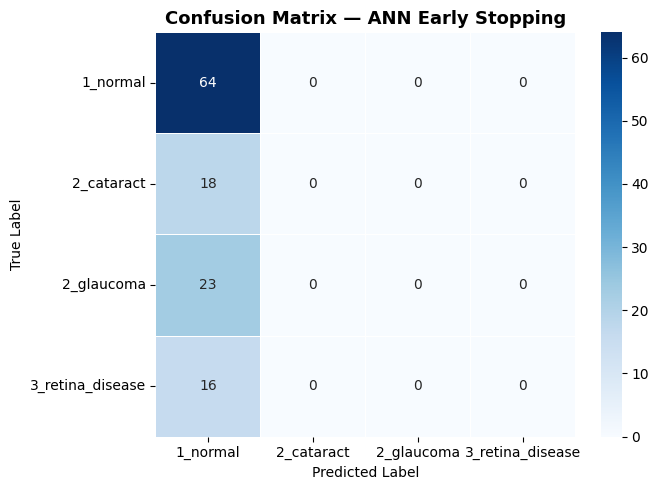


  ANN SGD
  Accuracy  : 52.89%
  Precision : 27.98%
  Recall    : 52.89%
  F1 Score  : 36.60%

  Per-Class Report:
                  precision    recall  f1-score   support

        1_normal       0.53      1.00      0.69        64
      2_cataract       0.00      0.00      0.00        18
      2_glaucoma       0.00      0.00      0.00        23
3_retina_disease       0.00      0.00      0.00        16

        accuracy                           0.53       121
       macro avg       0.13      0.25      0.17       121
    weighted avg       0.28      0.53      0.37       121



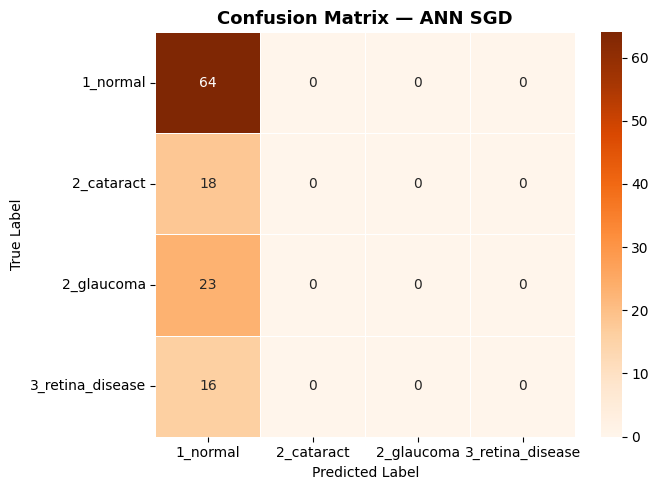


  Early Stopping vs SGD
  Metric         Early Stop          SGD
  --------------------------------------
  Accuracy           52.89%       52.89%
  Precision          27.98%       27.98%
  Recall             52.89%       52.89%
  F1 Score           36.60%       36.60%


⬇ FINAL MODEL EVALUATION — ANN vs CNN ⬇

  Final ANN (Combined Regularised)
  Accuracy  : 60.33%
  Precision : 42.95%
  Recall    : 60.33%
  F1 Score  : 48.14%

  Per-Class Report:
                  precision    recall  f1-score   support

        1_normal       0.58      1.00      0.74        64
      2_cataract       0.82      0.50      0.62        18
      2_glaucoma       0.00      0.00      0.00        23
3_retina_disease       0.00      0.00      0.00        16

        accuracy                           0.60       121
       macro avg       0.35      0.38      0.34       121
    weighted avg       0.43      0.60      0.48       121



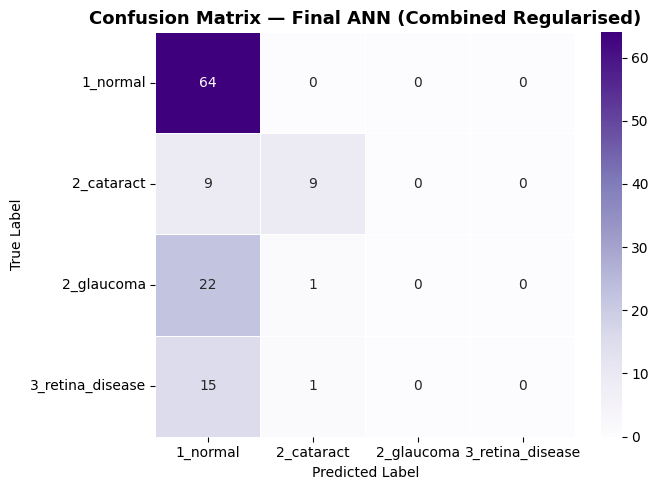


  Final CNN (BN + Dropout)
  Accuracy  : 65.29%
  Precision : 63.58%
  Recall    : 65.29%
  F1 Score  : 63.79%

  Per-Class Report:
                  precision    recall  f1-score   support

        1_normal       0.72      0.81      0.76        64
      2_cataract       0.57      0.67      0.62        18
      2_glaucoma       0.58      0.48      0.52        23
3_retina_disease       0.44      0.25      0.32        16

        accuracy                           0.65       121
       macro avg       0.58      0.55      0.56       121
    weighted avg       0.64      0.65      0.64       121



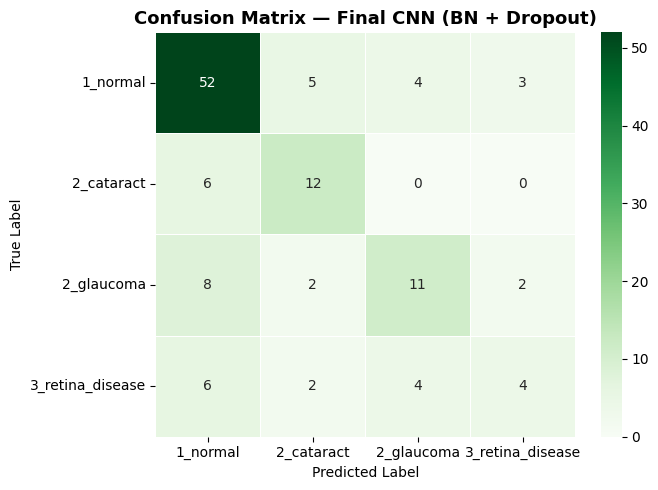


  FINAL COMPARISON — Best ANN vs Best CNN
  Metric            Final ANN      Final CNN   CNN Gain
  ------------------------------------------------------
  Accuracy             60.33%         65.29%   ↑4.96%
  Precision            42.95%         63.58%   ↑20.64%
  Recall               60.33%         65.29%   ↑4.96%
  F1 Score             48.14%         63.79%   ↑15.65%

  CNN outperforms ANN by : 4.96% accuracy
  This confirms CNNs are fundamentally better
  for image classification on small medical datasets.


NameError: name 'ann_results' is not defined

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = (
    testloader.dataset.dataset.classes
    if hasattr(testloader.dataset, 'dataset')
    else testloader.dataset.classes
)
print(f"Classes: {class_names}")




def get_predictions(model, dataloader):
    model.eval()
    model.to(device)
    all_preds  = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images       = images.to(device)
            outputs      = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


def compute_metrics(model, dataloader, class_names,
                    model_name="Model", cmap='Blues'):
    true_labels, pred_labels = get_predictions(model, dataloader)

    acc       = accuracy_score(true_labels, pred_labels) * 100
    precision = precision_score(true_labels, pred_labels,
                                average='weighted', zero_division=0) * 100
    recall    = recall_score(true_labels, pred_labels,
                             average='weighted', zero_division=0) * 100
    f1        = f1_score(true_labels, pred_labels,
                         average='weighted', zero_division=0) * 100

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.2f}%")
    print(f"  Precision : {precision:.2f}%")
    print(f"  Recall    : {recall:.2f}%")
    print(f"  F1 Score  : {f1:.2f}%")
    print(f"\n  Per-Class Report:")
    print(classification_report(
        true_labels, pred_labels,
        target_names=class_names,
        zero_division=0
    ))

    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5
    )
    plt.title(f'Confusion Matrix — {model_name}',
              fontsize=13, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return {
        'model_name': model_name,
        'accuracy':   acc,
        'precision':  precision,
        'recall':     recall,
        'f1':         f1,
        'cm':         cm
    }




print("\n\n⬇ ANN EARLY STOPPING + SGD EVALUATION ⬇")

ann_es_results  = compute_metrics(
    ann_es,  testloader, class_names,
    "ANN Early Stopping", cmap='Blues'
)
ann_sgd_results = compute_metrics(
    ann_sgd, testloader, class_names,
    "ANN SGD",            cmap='Oranges'
)

# ── Quick comparison between the two ────────────────────────────
print(f"\n{'='*55}")
print(f"  Early Stopping vs SGD")
print(f"{'='*55}")
print(f"  {'Metric':<12} {'Early Stop':>12} {'SGD':>12}")
print(f"  {'-'*38}")
for metric, label in zip(
    ['accuracy', 'precision', 'recall', 'f1'],
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
):
    print(f"  {label:<12} "
          f"{ann_es_results[metric]:>11.2f}% "
          f"{ann_sgd_results[metric]:>11.2f}%")




print("\n\n⬇ FINAL MODEL EVALUATION — ANN vs CNN ⬇")

final_ann_results = compute_metrics(
    ann_l2,      testloader, class_names,
    "Final ANN (Combined Regularised)", cmap='Purples'
)
final_cnn_results = compute_metrics(
    model_bn_dropout,  testloader, class_names,
    "Final CNN (BN + Dropout)",         cmap='Greens'
)




print(f"\n{'='*60}")
print(f"  FINAL COMPARISON — Best ANN vs Best CNN")
print(f"{'='*60}")
print(f"  {'Metric':<12} {'Final ANN':>14} {'Final CNN':>14} {'CNN Gain':>10}")
print(f"  {'-'*54}")

for metric, label in zip(
    ['accuracy', 'precision', 'recall', 'f1'],
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
):
    a     = final_ann_results[metric]
    c     = final_cnn_results[metric]
    delta = c - a
    arrow = "↑" if delta > 0 else "↓"
    print(f"  {label:<12} {a:>13.2f}% {c:>13.2f}% "
          f"  {arrow}{abs(delta):.2f}%")

print(f"\n  CNN outperforms ANN by : "
      f"{final_cnn_results['accuracy'] - final_ann_results['accuracy']:.2f}% accuracy")
print(f"  This confirms CNNs are fundamentally better")
print(f"  for image classification on small medical datasets.")
print(f"{'='*60}")




all_ann = [
    ann_results,           # ANN Baseline      — from previous cell
    ann_dropout_results,   # ANN Dropout        — from previous cell
    ann_bn_results,        # ANN BatchNorm      — from previous cell
    ann_l2_results,        # ANN L2             — from previous cell
    ann_es_results,        # ANN Early Stopping — computed above
    ann_sgd_results,       # ANN SGD            — computed above
    ann_combined_results,  # ANN Combined       — from previous cell
]

model_names = [r['model_name'].replace("ANN ", "") for r in all_ann]
accuracies  = [r['accuracy']   for r in all_ann]
precisions  = [r['precision']  for r in all_ann]
recalls     = [r['recall']     for r in all_ann]
f1s         = [r['f1']         for r in all_ann]

x   = np.arange(len(model_names))
w   = 0.2
fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(x - 1.5*w, accuracies, w, label='Accuracy',  color='steelblue')
ax.bar(x - 0.5*w, precisions, w, label='Precision', color='orange')
ax.bar(x + 0.5*w, recalls,    w, label='Recall',    color='green')
ax.bar(x + 1.5*w, f1s,        w, label='F1 Score',  color='red')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Score %')
ax.set_title('All ANN Models — Accuracy, Precision, Recall, F1',
             fontweight='bold', fontsize=13)
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=25, color='gray', linestyle='--',
           alpha=0.5, label='Random chance (25%)')

plt.tight_layout()
plt.show()

## Dataset Images

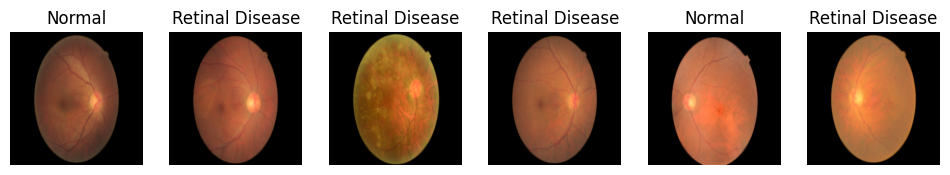

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['Normal', 'Cataract', 'Glaucoma', 'Retinal Disease']

def show_images(loader):
    data_iter = iter(loader)
    images, labels = next(data_iter)

    fig, axes = plt.subplots(1, 6, figsize=(12, 4))

    for i in range(6):
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5  # unnormalize if used (0.5,0.5,0.5)

        axes[i].imshow(img)
        axes[i].set_title(classes[labels[i]])
        axes[i].axis('off')

    plt.show()

# Call this
show_images(trainloader)